----

## **<p align="center"><b>Patrones de compra y comportamiento de clientes en Instacart</b></p>**

## **Introducción**

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.

Analizaremos los hábitos de compra de los clientes de Instacart mediante técnicas de preprocesamiento de datos y análisis exploratorio (EDA) para identificar patrones en los pedidos, frecuencia de compra, productos más populares y comportamiento de recompra.


## **Datos**

A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

### **Paso 1. Lectura de los datos**


In [1]:
# importar librerías
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
# leer conjuntos de datos en los DataFrames
instarcart_orders = pd.read_csv("instacart_orders.csv", sep = ';')

products = pd.read_csv("products.csv", sep = ';')

order_products = pd.read_csv("order_products.csv", sep = ';')

aisles = pd.read_csv("aisles.csv", sep = ';')

departments = pd.read_csv("departments.csv", sep = ';')

In [3]:
# mostrar información del DataFrame
instarcart_orders.info(show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [4]:
# mostrar información del DataFrame
products.info(show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [5]:
# mostrar información del DataFrame
order_products.info(show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [6]:
# mostrar información del DataFrame
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [7]:
# mostrar información del DataFrame
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


**Conclusiones intermedias sobre el Paso 1**

- **instacard_orders**
    - Cuenta con 6 columnas. 
    - De acuerdo a la información contenida en cada columna, el tipo de datos de las primeras 5 es el adecuado, sin embargo, en la última (*days_since_prior_order*: número de días transcurridos desde que este cliente hizo su pedido anterior) es *float64* y debería ser un entero.
    - La columna *days_since_prior_order* es la única que tiene valores nulos (28,819)


- **products**
    - Cuenta con 4 columnas.
    - El tipo de datos es el adecuado para cada columna.
    - La columna *product_name* tiene valores nulos (1258)


- **order_products**
    - Cuenta con 4 columnas.
    - El tipo de datos de la columna *add_to_cart_order* (orden secuencial en el que se añadió cada artículo en el carrito) debería ser entero en lugar de flotante.
    - Las últimas dos columnas, tiene valores nulos


- **aisles**
    - Cuenta con 2 columnas.
    - El tipo de datos es el adecuado.
    - No cuenta con valores nulos.


- **departments**
    - Cuenta con 2 columnas.
    - El tipo de datos es el adecuado.
    - No cuenta con valores nulos.

## **Paso 2. Preprocesamiento de los datos**

### `orders`

In [8]:
# Pedidos duplicados
instarcart_orders.duplicated().sum()

np.int64(15)

In [9]:
instarcart_orders[instarcart_orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


¿Qué tienen en común?

- Hay 15 líneas duplicadas.
  
- En todos los casos, el día en el que se hicieron los pedidos es el miércoles y la hora del día en que se hizo es a las 2:00 am.

- Por otro lado, en algunos casos, el número de días transcurridos desde el pedido anterior es NaN, lo que se puede deber a que es el primer pedido del cliente o que aún no se registra en el sistema.

In [10]:
# Pedidos que se hicieron el miércoles a las 2:00 a.m.
instarcart_orders[(instarcart_orders['order_dow'] == 3) & (instarcart_orders['order_hour_of_day'] == 2)]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
...,...,...,...,...,...,...
457013,3384021,14881,6,3,2,30.0
458816,910166,164782,18,3,2,4.0
459635,1680532,106435,6,3,2,21.0
468324,222962,54979,59,3,2,3.0


¿Qué sugiere este resultado?

- Tenemos 121 pedidos realizados el día miércoles a las 2:00 am.
  
- Es notorio que este resultado, tambien se muestran aquellos valores que están duplicados.

In [11]:
# Eliminamos los pedidos duplicados
instarcart_orders = instarcart_orders.drop_duplicates().reset_index(drop = True)

### `products`

In [12]:
# Verificamos si hay filas totalmente duplicadas
products.duplicated().sum()

np.int64(0)

In [13]:
# Revisar si hay ID de productos duplicados
products['product_id'].duplicated().sum()

np.int64(0)

In [14]:
# Revisar si hay nombres duplicados de productos

products['product_name'] = products['product_name'].str.upper()
print("Número de nombres duplicados de productos:", products['product_name'].duplicated().sum())

Número de nombres duplicados de productos: 1361


In [15]:
# Revisamos si hay nombres duplicados de productos no faltantes

#Eliminamos filas con valores ausentes
products_sin_ausentes = products.dropna(subset = ['product_name'])


#verificamos si hay nombres duplicados de productos no faltantes
print(f"Cantidad de nombres duplicados: {products_sin_ausentes['product_name'].duplicated().sum()}")

Cantidad de nombres duplicados: 104


En este caso, no es anormal encontrar nombres duplicados y no es necesario eliminarlos. Tienen diferente id, por lo tanto, es posible que sean diferentes versiones de un mismo producto.

### `departments`

In [16]:
# Revisamos si hay filas totalmente duplicadas
departments.duplicated().sum()

np.int64(0)

In [17]:
# Revisamos si hay IDs duplicadas de departamentos
departments['department_id'].duplicated().sum()

np.int64(0)

### `aisles`

In [18]:
# Revisamos si hay filas totalmente duplicadas
aisles.duplicated().sum()

np.int64(0)

In [19]:
# Revisamos si hay IDs duplicadas de pasillos
aisles['aisle_id'].duplicated().sum()

np.int64(0)

### `order_products`

In [20]:
# Revisamos si hay filas totalmente duplicadas
order_products.duplicated().sum()

np.int64(0)

In [21]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
columnas = ['order_id', 'add_to_cart_order', 'reordered']

filas_duplicadas = order_products[order_products.duplicated(subset = columnas)]
filas_duplicadas.sort_values(by = 'order_id')

,order_id,product_id,add_to_cart_order,reordered
1961551,61355,9421,NaN,0
433099,61355,44238,NaN,0
3905245,61355,38886,NaN,0
1643702,61355,13687,NaN,0
454645,61355,40268,NaN,0
...,...,...,...,...
137029,3347453,30727,NaN,0
219403,3347453,18782,NaN,0
2772397,3383594,46710,NaN,0
3784932,3383594,49144,NaN,1


En este DataFrame, tenemos duplicados engañosos. De acuerdo a mi análisis, si los valores de filas de las columnas *'order_id', 'add_to_cart_order', 'reordered'* se repiten, entonces es un duplicado engañoso, porque los pedidos son únicos, aunque un mismo cliente haga varios pedidos, siguen siendo únicos.

Además, notamos que cuando se repitan los valores de *order_id*, la tercer columna tiene valores ausentes.

### **Encontrar y eliminar los valores ausentes**

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products`

In [22]:
# Valores ausentes en la columna 'product_name'
products[products['product_name'].isna()]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Tenemos que hay 1258 valores ausentes en la columna *product_name*, además podemos notar con el método unique(), que *aisle_id* siempre toma valores de 100 y *department_id* toma valores de 21, por lo que, no hay nombre del producto, pero podemos obtenerlo porque sabemos que están en el pasillo de víveres número 100 y el departamento es 21.

In [23]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
products[products['product_name'].isna()]['aisle_id'].unique()

array([100])

Como se mencionó con aterioridad, hay 1258 valores ausentes en la columna mencionada y en todas estas filas, el pasillo tiene un ID de 100.

In [24]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
products[products['product_name'].isna()]['department_id'].unique()

array([21])

En todas las filas de valores ausentes de la columna mencionada, el departamento de víveres corresponde al ID 21.

In [25]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
print(aisles.query("aisle_id == 100"))

print(departments.query("department_id == 21"))

    aisle_id    aisle
99       100  missing
    department_id department
20             21    missing


- La categoría de pasillo que corresponde al aisle_id = 100 es **missing**
- El nombre del deartamento que corresponde al departement_id = 21 es **missing**

In [26]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'].fillna('unknown', inplace = True)

products['product_name'].isna().sum()

C:\Users\aleja\AppData\Local\Temp\ipykernel_35272\3027906148.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_name'].fillna('unknown', inplace = True)


np.int64(0)

En el dataFrame de productos, se rellenaron los valores ausentes de la columna *product_name* con la palabra *unknown* con el método fillna(). Además, se identificó que pasillo y que departamento correpondian a dichos valores mediante query().

### `orders`

In [27]:
# Valores ausentes
instarcart_orders.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [28]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
instarcart_orders.query("order_number != 1 and order_number.isnull()")

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


Con el método isna().sum(), notamos que la única columna con valores ausentes es *days_since_prior_order*, con un total de 28819 valores. 

Además, se comprobó que no hay valores ausentes donde el pedido del cliente sea el primero. De la misma manera, se corrobora con el metodo info(), pues nos dice que no hay valores ausentes en la columna *order_number*

### `order_products`

In [29]:
# Valores ausentes
order_products.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [30]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
min = order_products['add_to_cart_order'].min()
max = order_products['add_to_cart_order'].max()

print(f"El valor mínimo de la columna add_to_cart_order es: {min} y el valor máximo es: {max}")

El valor mínimo de la columna add_to_cart_order es: 1.0 y el valor máximo es: 64.0


Es este DataFrame, la única columna con valores con valores ausentes es *add_to_cart_order*, con un total de 836 valores.

Por otro lado, el valor mínimo y máximo de esta misma, es 1 y 64 respectivamente.

In [31]:
# IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
lista_ordenes_ausentes = order_products[order_products['add_to_cart_order'].isnull()]['order_id'].unique()

In [32]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

#lista de ordenes con valores ausentes en 'add_to_cart_order'
lista_ordenes_ausentes = order_products[order_products['add_to_cart_order'].isnull()]['order_id'].unique()

#pedidos donde el ID este en la lista 'lista_ordenes_ausentes'
pedidos_con_na = order_products[order_products['order_id'].isin(lista_ordenes_ausentes)]

#Agrupamos por 'order_id' y contamos cuantos productos hay en esos pedidos
productos_por_pedido = pedidos_con_na.groupby('order_id')['product_id'].count()

minimo = productos_por_pedido.min()

mas_64_products = (productos_por_pedido > 64).all()

print(f"El valor mínimo de productos por pedido es: {minimo}")

print()

print(f"¿Todos los pedidos con valores ausentes tienen más de 64 productos?: {mas_64_products}")


El valor mínimo de productos por pedido es: 65

¿Todos los pedidos con valores ausentes tienen más de 64 productos?: True


Tenemos que el pedido más pequeño fue de 65 artículos. Además, todos los pedidos con valores ausentes tienen más de 64 productos.

In [33]:
# Remplaza los valores ausentes en la columna 'add_to_cart con 999 y convierte la columna al tipo entero.
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype('int')

print(order_products['add_to_cart_order'].dtypes)
print(order_products['add_to_cart_order'].isna().sum())

int64
0


- Como observamos con anterioridad, la columa *add_to_cart_order* era la única con valores austes.
- Estos fueron reemplazados por el entero 999.
- Finalmente, comprobamos que el tipo de dato sea el correcto y que ya no hay valores ausentes en dicha columna.

En el preprocesamiento de los datos, concluimos lo siguiente:

- Ya podemos trabajar con las bases de datos, pues las que contaban con valores ausentes, fueron reemplazados por otros valores, además se eliminaron la filas duplicadas.
- Por otro lado, se realizaron ciertas agrupaciones para conocer la estructura de los datos y familiarizarnos con ellos, como observar patrones, obtener mínimos y máximos, entre otros.
- Por último, en cada dataFrame se verificó que ya no existieran valores ausentes ni duplicados.

## **Paso 3. Análisis de los datos**

**1. Verifica que los valores sean razonables**

In [34]:
sorted(instarcart_orders['order_hour_of_day'].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23)]

In [35]:
sorted(instarcart_orders['order_dow'].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6)]

Los valores de ambas columnas son razonables, con horas de 0-23 y con  días de la semana de 0-6, empezando por domingo.

**2. Para cada hora del día, ¿cuántas personas hacen órdenes?**

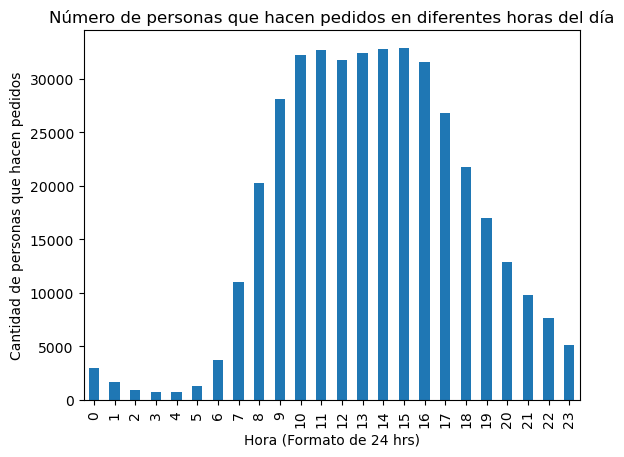

In [36]:
#Agrupamos por hora del día y contamos los valores únicos de la columna 'user_id' que representa los clientes
pedidos_por_hora = instarcart_orders.groupby('order_hour_of_day')['user_id'].nunique()

pedidos_por_hora.plot( kind = 'bar',
                       title = 'Número de personas que hacen pedidos en diferentes horas del día',
                       xlabel = 'Hora (Formato de 24 hrs)',
                       ylabel = 'Cantidad de personas que hacen pedidos'
                       )

plt.show()

- Tenemos que es un gráfica sesgada a la izquierda, pues las barras se agrupan a la derecha con cola a la izquierda.
- La hora donde las personas hacen más pedidos es a las 15:00
- El plazo de horas donde la gente hace más pedidos oscila entre las 10:00 am - 4:00pm

**3. ¿Qué día de la semana compran víveres las personas?**

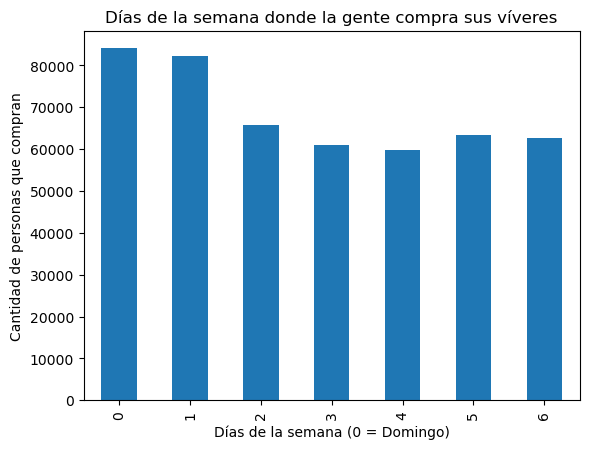

In [37]:
pedidos_por_dia = instarcart_orders.groupby('order_dow')['order_id'].nunique()
    
pedidos_por_dia.plot( kind = 'bar',
                      title = 'Días de la semana donde la gente compra sus víveres',
                      xlabel = 'Días de la semana (0 = Domingo)',
                      ylabel = 'Cantidad de personas que compran'
                      )

plt.show()

- El domingo es el día en el que las personas más hacen compras, seguido del lunes.
- El día en que menos compras realizan es el jueves.

**4. ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.**

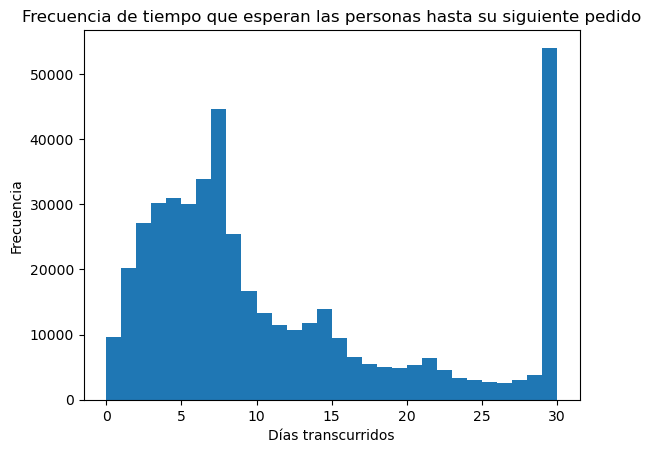

El valor mínimo de días transcurridos desde el pedido anterior es: 0.0 y el valor máximo es: 30.0


In [38]:
instarcart_orders['days_since_prior_order'].plot(kind = 'hist',
                                               bins = 30,
                                               title = 'Frecuencia de tiempo que esperan las personas hasta su siguiente pedido',
                                               xlabel = 'Días transcurridos',
                                               ylabel = 'Frecuencia')

plt.show()

min = instarcart_orders['days_since_prior_order'].min()
max = instarcart_orders['days_since_prior_order'].max()

print(f"El valor mínimo de días transcurridos desde el pedido anterior es: {min} y el valor máximo es: {max}")

- Este histograma no sigue alguna distribución conocida.
- Parece que no hay valores atípicos.
- Nuestra barra más alta es cuando han transcurrido 30 días desde el pedido anterior, por lo que es el valor más frecunte.
- El valor mínimo de días transcurridos desde el pedido anterior es 0, lo que nos dice que los clientes hacen pedidos muy seguidos, sin embargo, el histograma nos muestra que muy pocas personas esperan 0 días para hacer su próximo pedido.
- El valor máximo de días transcurridos desde el pedido anterior es 30. En el histograma es la barra más alta, sin embargo, las personas dejan pasar entre 1 a 7 días aproximadamente para hacer otro pedido.

**5. Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.**

In [39]:
#Filtramos el df por los días miércoles y sábados
df_miercoles = instarcart_orders.query("order_dow == 3")
df_sabados = instarcart_orders.query("order_dow == 6")

In [40]:
#Contamos el número de clientes que hace pedidos por hora en los dos días anteriores
clientes_por_hora_miercoles = df_miercoles.groupby('order_hour_of_day')['user_id'].count()
clientes_por_hora_sabados = df_sabados.groupby('order_hour_of_day')['user_id'].count()

In [41]:
df_concat = pd.concat([clientes_por_hora_miercoles, clientes_por_hora_sabados], axis = 'columns')
df_concat.columns = ['Pedidos por hora en miércoles', 'Pedidos por hora en sábado']

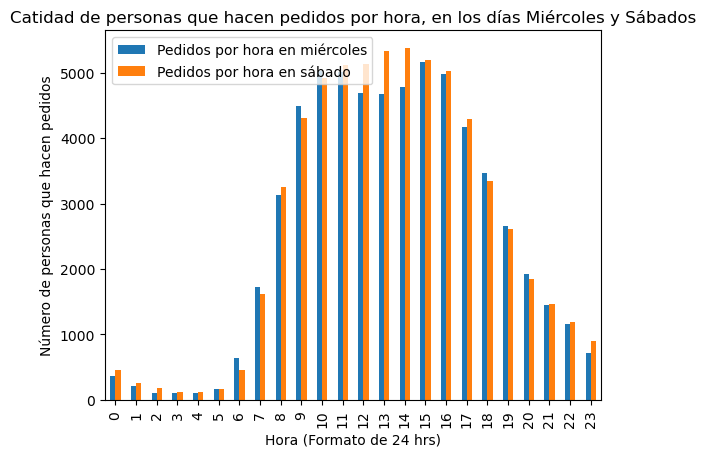

In [42]:
#Gráfico para el miércoles
df_concat.plot(kind = 'bar',
               title = 'Catidad de personas que hacen pedidos por hora, en los días Miércoles y Sábados',
               xlabel = 'Hora (Formato de 24 hrs)',
               ylabel = 'Número de personas que hacen pedidos')
plt.show()

- Podemos observar que tanto miércoles como sábado se distribuyen casi igual.
- En ambos días, hay más números de pedidos entre las 10:00 am y 4:00 pm, con una diferencia mayor en los sábados.

**6. ¿Cuál es la distribución para el número de pedidos por cliente?**

In [43]:
pedidos_por_clientes = instarcart_orders.groupby('order_number')['user_id'].count()

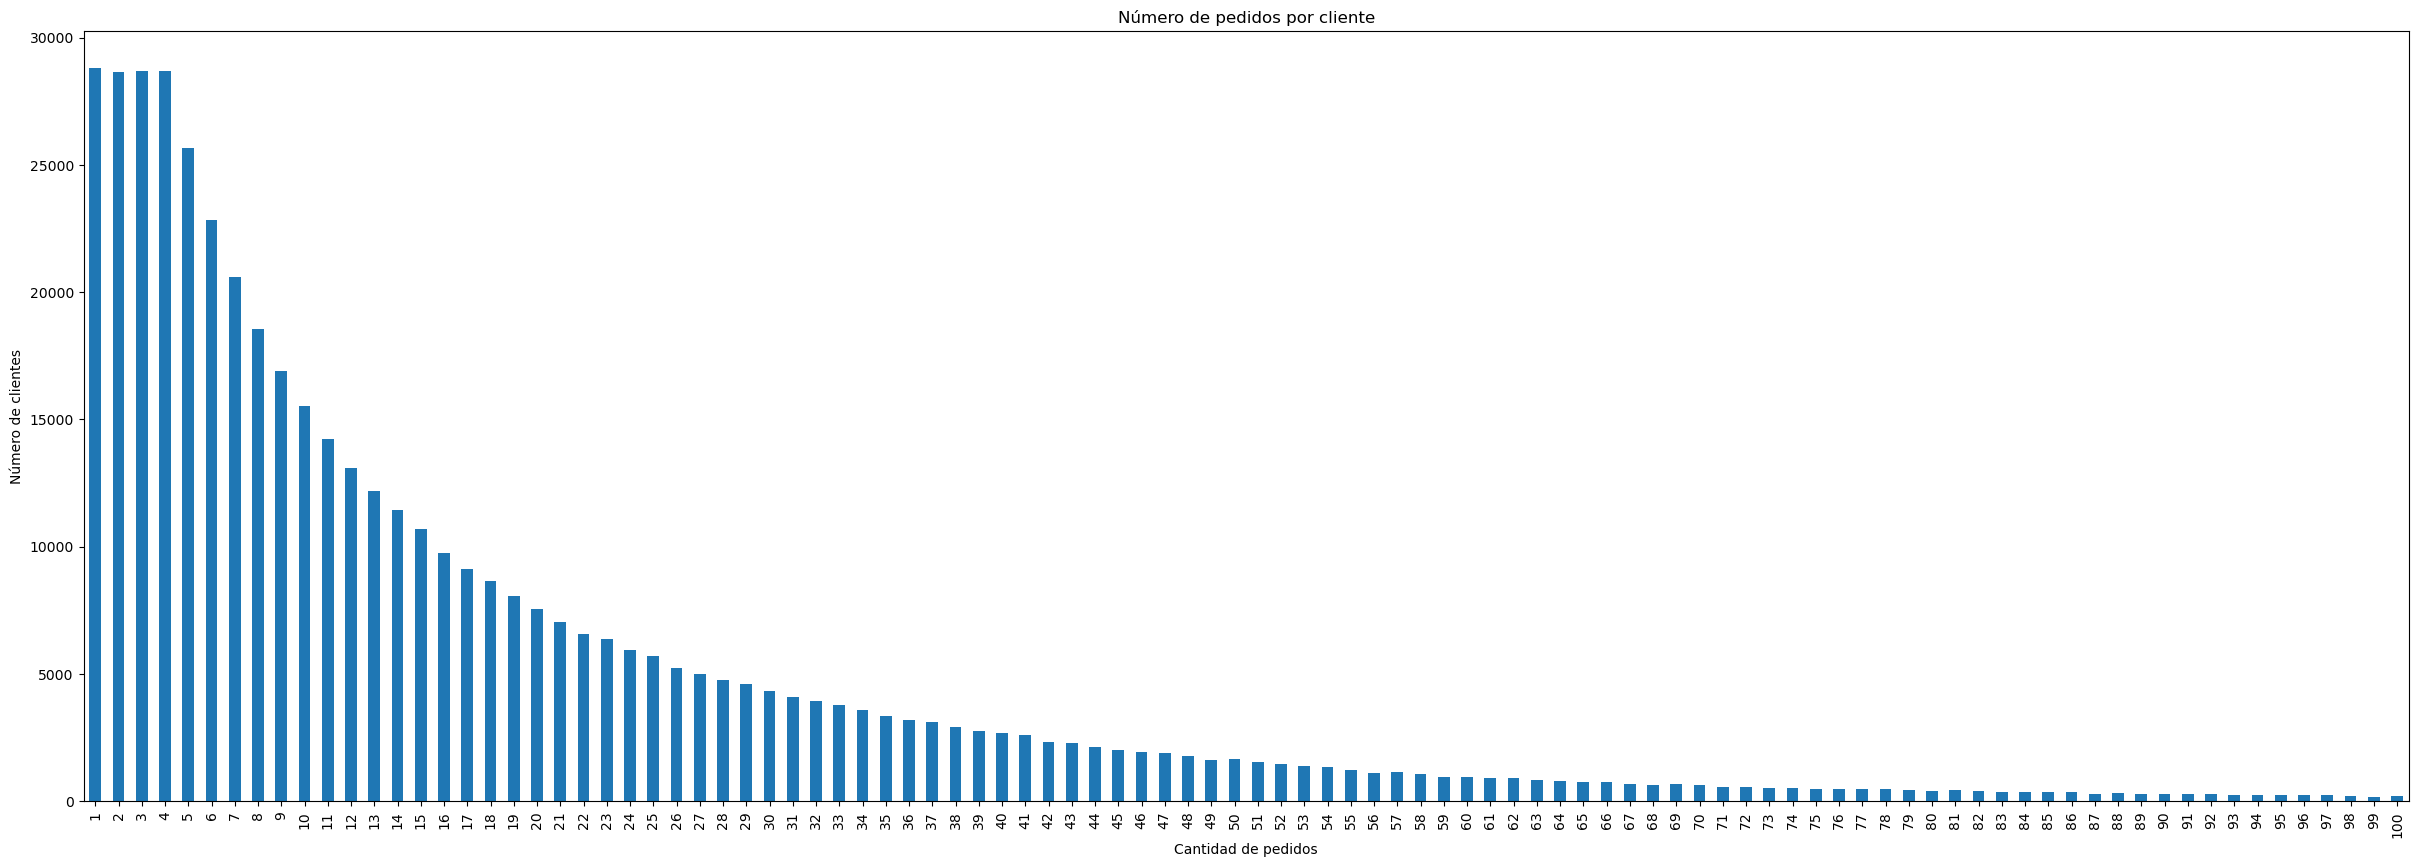

In [44]:
pedidos_por_clientes.plot(kind = 'bar',
                         title = 'Número de pedidos por cliente',
                         xlabel = 'Cantidad de pedidos',
                         ylabel = 'Número de clientes',
                         xlim = [0,100],
                         figsize = [30,10])
plt.show()

- El gráfico de número de pedidos por clientes muestra una distribución sesgada a la derecha. Esto nos dice que la mayoría de las personas hace pedidos bajos.
- El número de pedidos que en promedio hacen los clientes van desde 1 hasta 8 aproximadamente.

**7. ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?**

In [45]:
#Obtenemos los valores únicos y su recuento de cada producto
recuento_producto = order_products['product_id'].value_counts().reset_index()
recuento_producto.columns = ['product_id', 'count']
recuento_producto

,product_id,count
0,24852,66050
1,13176,53297
2,21137,37039
3,21903,33971
4,47209,29773
...,...,...
45568,47987,1
45569,26408,1
45570,24435,1
45571,36946,1


In [46]:
#Unir el dataframe anterior con el del 'products' para saber el nombre 
both = recuento_producto.merge(products, on = 'product_id', how = 'left')

In [47]:
# 20 productos mas populares
both[['product_id', 'product_name']].head(20)

,product_id,product_name
0,24852,BANANA
1,13176,BAG OF ORGANIC BANANAS
2,21137,ORGANIC STRAWBERRIES
3,21903,ORGANIC BABY SPINACH
4,47209,ORGANIC HASS AVOCADO
5,47766,ORGANIC AVOCADO
6,47626,LARGE LEMON
7,16797,STRAWBERRIES
8,26209,LIMES
9,27845,ORGANIC WHOLE MILK


- Para obtener el top 20 de los productos más vendidos, primero creamos un dataFrame que devolviera los valores únicos de *product_id* y su recuento para saber cual es el más vendido.
- Posteriormente, combinamos el dataFrame con el de *products*  para saber el nombre correspondiente de cada ID.
- Finalmente, mostramos el top20 con head(20).
- La tabla del top20 nos muestra diferentes productos. Como se vió con anterioridad, los nombres de los productos no se repiten.

**8. ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?**

In [48]:
conteo_pedidos = order_products.groupby('order_id')['order_id'].count()

<Axes: title={'center': 'Cantidad de artículos que compra la gente en un pedido'}, xlabel='ID del Pedido', ylabel='Cantidad de artículos'>

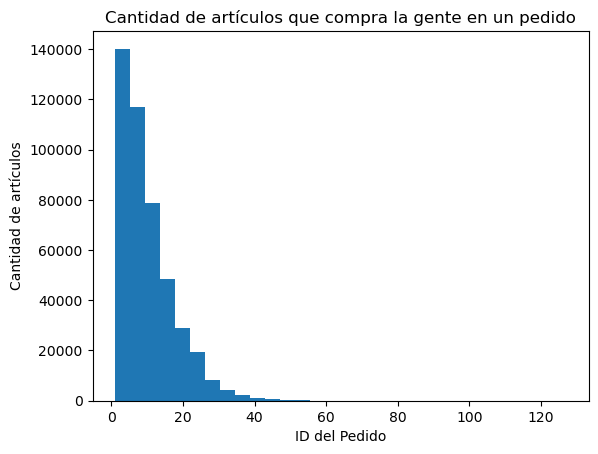

In [49]:
#histograma
conteo_pedidos.plot(kind = 'hist',
                    bins = 30,
                   title = 'Cantidad de artículos que compra la gente en un pedido',
                   xlabel = 'ID del Pedido',
                   ylabel = 'Cantidad de artículos')

- Tenemos que si hay pedidos muy grandes.
- El más pequeño oscila entre 50 productos.

**9. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?**

In [50]:
articulos_pedidos = order_products.query("reordered == 1")
articulos_pedidos

,order_id,product_id,add_to_cart_order,reordered
1,567889,1560,1,1
2,2261212,26683,1,1
3,491251,8670,35,1
4,2571142,1940,5,1
5,2456893,21616,4,1
...,...,...,...,...
4544999,1622300,24852,1,1
4545000,1125324,40600,6,1
4545002,577211,15290,12,1
4545004,692640,47766,4,1


In [51]:
#ID de los productos 

id_productos = articulos_pedidos['product_id'].value_counts().reset_index()
#id_productos.columns = ['product_id', 'count']
id_productos.head()


,product_id,count
0,24852,55763
1,13176,44450
2,21137,28639
3,21903,26233
4,47209,23629


In [52]:
#Unimos ambas tablas para obtener el nombre
both = id_productos.merge(products, on = 'product_id', how = 'left')

In [53]:
#Mostrar el ID del producto y el nombre de los primeros 20 articulos más pedidos
both[['product_id', 'product_name']].head(20)

,product_id,product_name
0,24852,BANANA
1,13176,BAG OF ORGANIC BANANAS
2,21137,ORGANIC STRAWBERRIES
3,21903,ORGANIC BABY SPINACH
4,47209,ORGANIC HASS AVOCADO
5,47766,ORGANIC AVOCADO
6,27845,ORGANIC WHOLE MILK
7,47626,LARGE LEMON
8,27966,ORGANIC RASPBERRIES
9,16797,STRAWBERRIES


- Primero filtramos los pedidos en donde el cliente ya haya pedido ese producto.
- Contamos los valores de los productos únicos
- Unimos con la tabla products para saber el nombre correspondiente a cada ID
- Mostramos el top20 con head(20)
- Nos arrojan 20 productos diferentes.


**10. Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?**

In [54]:
agg_dict = {'reordered' : 'sum', 'order_id': 'count'}

In [55]:
proporcion = order_products.groupby('product_id').agg(agg_dict)

In [56]:
proporcion['proporcion'] = proporcion['reordered'] / proporcion['order_id']
proporcion

,reordered,order_id,proporcion
product_id,,,
1,158,280,0.564286
2,0,11,0.000000
3,31,42,0.738095
4,25,49,0.510204
7,1,2,0.500000
...,...,...,...
49690,4,5,0.800000
49691,31,72,0.430556
49692,5,12,0.416667


- Para obtener la proporción de pedidos que se vuelven a pedir, se debe de dividir: veces que el cliente ha pedido / total de pedidos
- Para esto, usamos el método *agg()*, donde sumamos las veces en las que el cliente ha pedido y contamos cada pedido
- Aplicamos el método a cada grupo creado por groupby
- Finalmente creamos una columna con la proporción.


**11. Para cada cliente, ¿qué proporción de sus productos ya los había pedido?**

In [57]:
#Unimos las tablas instacard_orders y order_products 
productos = instarcart_orders.merge(order_products, on = 'order_id')

In [58]:
agg_dict = {'reordered': 'sum', 'product_id':'count'}

proporcion = productos.groupby('user_id').agg(agg_dict)

proporcion['proporcion'] = proporcion['reordered'] / proporcion['product_id']
proporcion = proporcion.reset_index()
proporcion

,user_id,reordered,product_id,proporcion
0,2,1,26,0.038462
1,4,0,2,0.000000
2,5,8,12,0.666667
3,6,0,4,0.000000
4,7,13,14,0.928571
...,...,...,...,...
149621,206203,6,27,0.222222
149622,206206,15,21,0.714286
149623,206207,41,46,0.891304
149624,206208,87,125,0.696000


Al igual que el caso anterior, se usó el método *agg()*, se aplicó al grupo creado por groupby y finalmente se hizo el cálculo en una nueva columna

**12. ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?**

In [59]:
#obtenemos un dataframe donde el orden en el que añadieron artículos al carrito sea el primero
primer_articulo = order_products.query("add_to_cart_order == 1")

In [60]:
agrupar_por_producto = primer_articulo['product_id'].value_counts().reset_index()
agrupar_por_producto.columns = ['product_id', 'count']

#ordenamos de mayor a menor
agrupar_por_producto.sort_values('count', ascending = False)

,product_id,count
0,24852,15562
1,13176,11026
2,27845,4363
3,21137,3946
4,47209,3390
...,...,...
21192,1191,1
21191,3377,1
21190,28191,1
21189,30514,1


In [61]:
#unimos con el df 'products' para obtener el nombre del producto
both = agrupar_por_producto.merge(products, on = 'product_id', how = 'left')

In [62]:
both.head(20)[['product_id', 'product_name']]

,product_id,product_name
0,24852,BANANA
1,13176,BAG OF ORGANIC BANANAS
2,27845,ORGANIC WHOLE MILK
3,21137,ORGANIC STRAWBERRIES
4,47209,ORGANIC HASS AVOCADO
5,21903,ORGANIC BABY SPINACH
6,47766,ORGANIC AVOCADO
7,19660,SPRING WATER
8,16797,STRAWBERRIES
9,27966,ORGANIC RASPBERRIES


- Para obtener los 20 principales artículos que las personas ponen primero en sus carritos, primero filtramos la tabla *order_products* donde el orden secuencial en el que se añade un artículo al carrito sea igual a 1.
- Después, agrupamos por producto y contamos cuantas veces aparecen para poder obtener el top20.
- Luego, unimos con la tabla de productos para obtener el nombre del producto
- Finalmente, imprimos el top20 donde se muestra el id y nombre del artículo.

## **Conclusion**

Las bases de datos proporcionadas nos permitieron aplicar métodos, funciones y gráficos para obtener respuestas a ciertas cuestiones.

Primero que nada, obtuvimos una descripción de los datos para saber como se componen.

Posteriormente,preprocesamos los datos en donde verificamos y corregimos errores o datos inconsistente como los ausentes o duplicados.

Al realizar análisis, obtuvimos algunos resultados relevantes, por ejemplo, las personas realizan más pedidos de 10:00 am a 4:00pm, se realizan más compras los domingos, los clientes no esperan muchos días para realizar otro pedido, el número de pedidos que en promedio hacen los clientes van desde 1 hasta 8 aproximadamente, el producto más pedido son Bananas y Bag of organic bananas y son uno de los productos que las personas ponen primero en su carrito.

Además, se conoció la proporción de veces que pide y que vuelve a pedir un cliente y la proporción de productos que ya han pedido.

Finalmente, los hábitos de las personas sobre compras en Instacart son similares, siguen un patrón y posiblemente pueden variar en distintas épocas del año.